In [1]:
import sys

sys.path.append("../..")

In [9]:
from matplotlib import pyplot as plt 
import numpy as np 
import torch

from torchvision import transforms

from zennit.attribution import Gradient
from zennit.composites import EpsilonGammaBox

from torch.nn import functional as F

from xaikd import models, datasets, attributors

In [3]:
model = models.get_model("cifar100-vgg11-p1")

In [4]:
from torchvision.models import vgg

In [41]:
model

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (11): Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (12): ReLU(inplace=True)
    (13): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (14): ReLU(inplace=True)
    (15): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
 

In [11]:
dataset = datasets.construct("cifar100")

In [12]:
dataset.input_statistics

((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.201))

In [13]:
dl = dataset.loader(train_split=True, batch_size=10)

In [14]:
x, y = next(iter(dl))

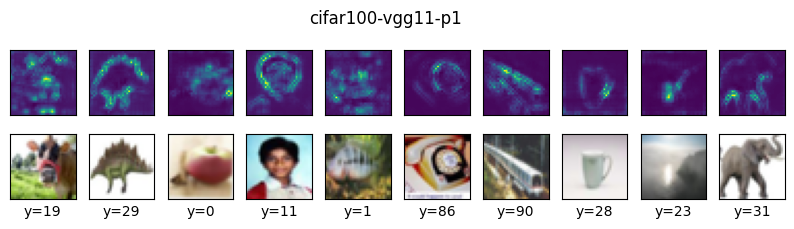

In [39]:
def explain(model, data, target):

    # create the attributor, specifying model and composite
    with attributors.make_attributor_for(model, dataset.input_statistics) as attributor:
    # compute the model output and attribution
        output, attribution = attributor(data, F.one_hot(target, num_classes=100))
        
    return output, attribution


def viz(model_name):
    
    model = models.get_model(model_name)
    
    logits, heatmaps = explain(model, x, y)

    ncols = x.shape[0]
    nrows = 2
    plt.figure(figsize=(1*ncols, nrows*1))
    
    plt.suptitle(model_name, y=1.07)
    for i in range(ncols):
        
        plt.subplot(nrows, ncols, ncols + i+1)
        
        img = torch.permute(x[i, :, :, :], [1, 2, 0])
        img = img * torch.tensor(dataset.input_statistics[1]) + torch.tensor(dataset.input_statistics[0])
        
        img = np.clip(img, 0, 1)
        plt.xlabel(f"y={y[i]}")

        plt.imshow(img)
        plt.xticks([]); plt.yticks([])
        
        plt.subplot(nrows, ncols, i+1)

        heatmap = heatmaps[i, ].detach().cpu().numpy().sum(axis=0)
        plt.imshow(heatmap)

        plt.xticks([]); plt.yticks([])

viz("cifar100-vgg11-p1")

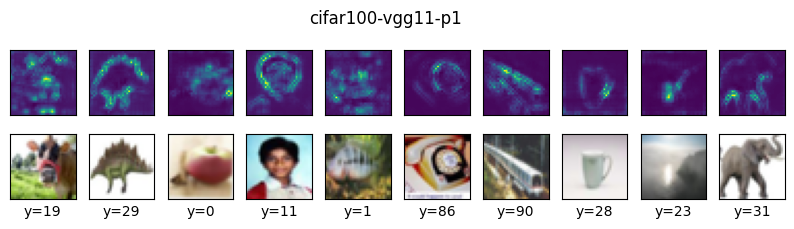

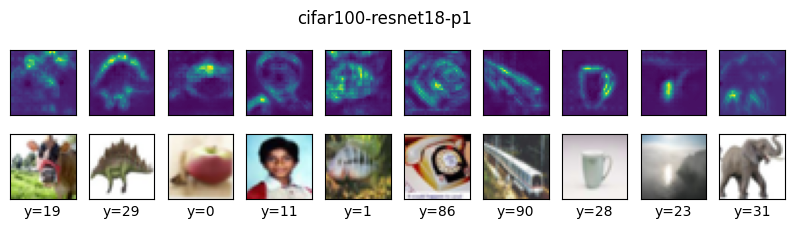

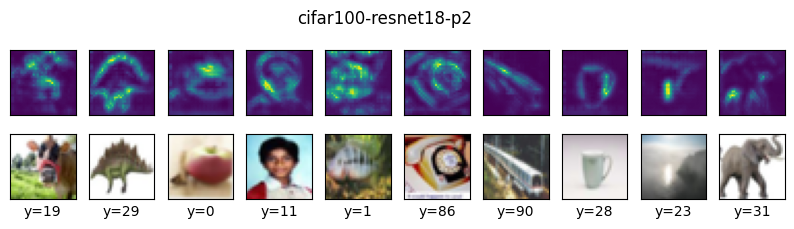

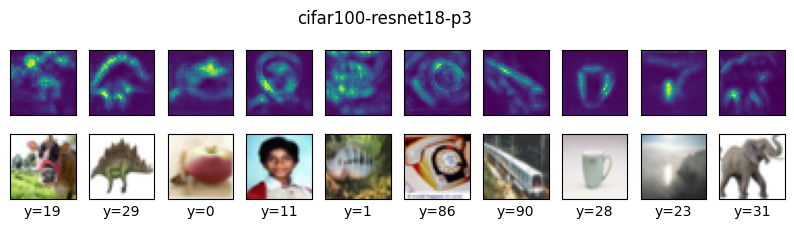

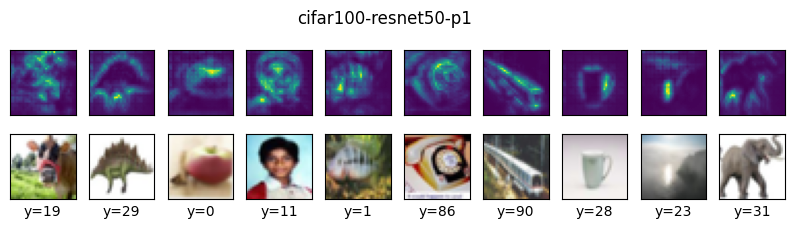

In [40]:
for model_name in [
    "cifar100-vgg11-p1",
    "cifar100-resnet18-p1",
    "cifar100-resnet18-p2",
    "cifar100-resnet18-p3",
    "cifar100-resnet50-p1",
]:
    viz(model_name)